# OSD-352 Data Exploration

Exploring the Rodent Research-3 brain snRNA-seq dataset to understand:
- Data structure and dimensions
- Sample composition and mapping
- Quality control metrics
- Condition labels (Space Flight vs Ground Control)

In [44]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Load Data

In [45]:
# Load 10X HDF5 file
adata = sc.read_10x_h5('../data/OSD-352/GLDS-352_snRNA-Seq_filtered_feature_bc_matrix.h5')

print(f"Cells: {adata.n_obs:,}")
print(f"Genes: {adata.n_vars:,}")

Cells: 32,243
Genes: 32,285


/Users/harry/miniforge3/envs/spaceGen/lib/python3.12/site-packages/anndata/_core/anndata.py:1825: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


## Sample Mapping

Map cell barcode suffixes to sample names using metadata

In [46]:
# Extract sample ID from cell barcodes (suffix after '-')
adata.obs['sample_id'] = adata.obs.index.str.split('-').str[1]
print("\nCells per barcode suffix:")
print(adata.obs['sample_id'].value_counts().sort_index())


Cells per barcode suffix:
sample_id
1     1140
2     5333
3     5960
4     4622
5    15188
Name: count, dtype: int64


In [47]:
# Load assay metadata to verify cell counts
assay_meta = pd.read_csv('../data/OSD-352/a_OSD-352_transcription-profiling_single-cell-rna-sequencing_illumina.txt', sep='\t')

print("\nCell counts from metadata:")
print(assay_meta[['Sample Name', 'Parameter Value[Total Cell Count]']])


Cell counts from metadata:
      Sample Name  Parameter Value[Total Cell Count]
0  RR3_BRN_FLT_F1                              15188
1  RR3_BRN_FLT_F2                               1140
2  RR3_BRN_FLT_F7                               5333
3   RR3_BRN_GC_G8                               5960
4   RR3_BRN_GC_G9                               4622


In [48]:
# Create mapping based on matching cell counts
suffix_to_sample = {
    '1': 'RR3_BRN_FLT_F2',  # 1,140 cells
    '2': 'RR3_BRN_FLT_F7',  # 5,333 cells
    '3': 'RR3_BRN_GC_G8',   # 5,960 cells
    '4': 'RR3_BRN_GC_G9',   # 4,622 cells
    '5': 'RR3_BRN_FLT_F1'   # 15,188 cells
}

sample_to_condition = {
    'RR3_BRN_FLT_F1': 'Space Flight',
    'RR3_BRN_FLT_F2': 'Space Flight',
    'RR3_BRN_FLT_F7': 'Space Flight',
    'RR3_BRN_GC_G8': 'Ground Control',
    'RR3_BRN_GC_G9': 'Ground Control'
}

# Add to AnnData object
adata.obs['sample_name'] = adata.obs['sample_id'].map(suffix_to_sample)
adata.obs['condition'] = adata.obs['sample_name'].map(sample_to_condition)

print("\nSample mapping verification:")
print(adata.obs.groupby(['sample_id', 'sample_name', 'condition']).size())

print("\nCondition distribution:")
print(adata.obs['condition'].value_counts())


Sample mapping verification:
sample_id  sample_name     condition     
1          RR3_BRN_FLT_F2  Space Flight       1140
2          RR3_BRN_FLT_F7  Space Flight       5333
3          RR3_BRN_GC_G8   Ground Control     5960
4          RR3_BRN_GC_G9   Ground Control     4622
5          RR3_BRN_FLT_F1  Space Flight      15188
dtype: int64

Condition distribution:
condition
Space Flight      21661
Ground Control    10582
Name: count, dtype: int64


## Quality Control Metrics

In [49]:
# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, inplace=True)

print("\nQC Summary:")
print(adata.obs[['n_genes_by_counts', 'total_counts']].describe())


QC Summary:
       n_genes_by_counts  total_counts
count       32243.000000  32243.000000
mean         1282.421518   2962.538818
std          1071.715101   4122.266602
min            31.000000     33.000000
25%           539.000000    780.000000
50%           928.000000   1550.000000
75%          1692.000000   3383.000000
max          9553.000000  74170.000000


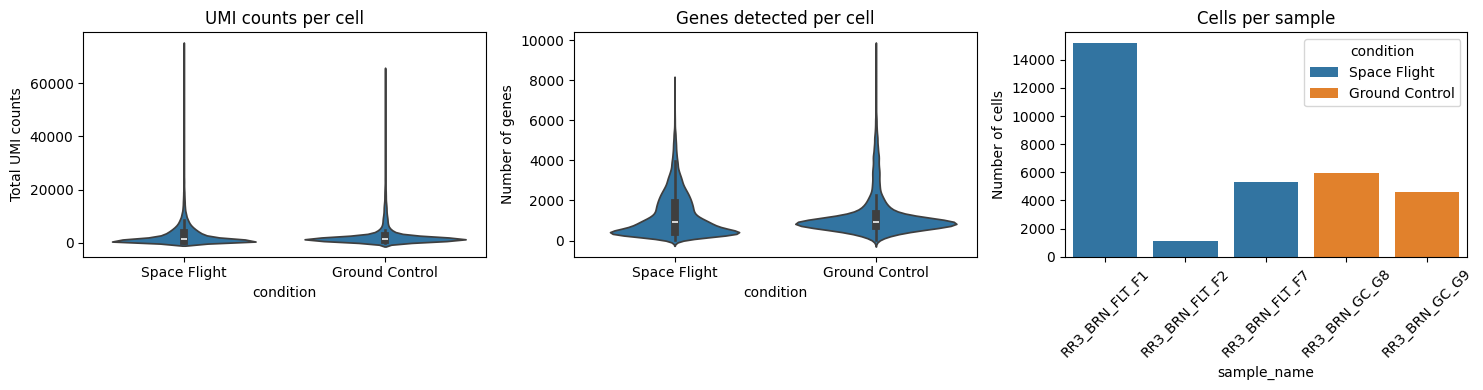

In [50]:
# Visualize QC metrics by condition
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# UMI counts per cell
sns.violinplot(data=adata.obs, x='condition', y='total_counts', ax=axes[0])
axes[0].set_ylabel('Total UMI counts')
axes[0].set_title('UMI counts per cell')

# Genes detected per cell
sns.violinplot(data=adata.obs, x='condition', y='n_genes_by_counts', ax=axes[1])
axes[1].set_ylabel('Number of genes')
axes[1].set_title('Genes detected per cell')

# Cell counts per sample
sample_counts = adata.obs.groupby(['sample_name', 'condition']).size().reset_index(name='count')
sns.barplot(data=sample_counts, x='sample_name', y='count', hue='condition', ax=axes[2])
axes[2].set_ylabel('Number of cells')
axes[2].set_title('Cells per sample')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## Mitochondrial Gene Percentage

In [51]:
# Calculate mitochondrial gene percentage
adata.var['mt'] = adata.var.index.str.startswith('mt-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], inplace=True)

print("\nMitochondrial gene percentage summary:")
print(adata.obs['pct_counts_mt'].describe())


Mitochondrial gene percentage summary:
count    32243.000000
mean         0.143697
std          0.436864
min          0.000000
25%          0.000000
50%          0.047427
75%          0.153345
max         31.134172
Name: pct_counts_mt, dtype: float64


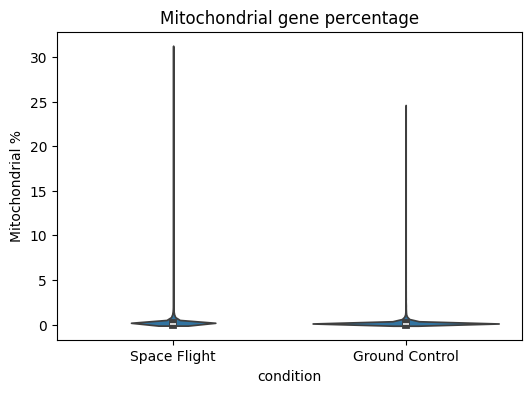

In [52]:
# Visualize mitochondrial percentage by condition
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
sns.violinplot(data=adata.obs, x='condition', y='pct_counts_mt', ax=ax)
ax.set_ylabel('Mitochondrial %')
ax.set_title('Mitochondrial gene percentage')
plt.show()

## Summary

<span style='color:steelblue;'> **Dataset:** OSD-352 (Rodent Research-3 brain snRNA-seq) <span>
- 32,243 cells across 5 samples
- 32,285 genes (mm10 genome)
- 3 Space Flight samples (21,661 cells)
- 2 Ground Control samples (10,582 cells)

<span style='color:steelblue;'> **Key Observations:** <span>
- Similar overall QC distributions between conditions
- Sample imbalance: F1 has 15k cells, F2 has only 1k cells
- Median UMI: ~1,500-2,000 per cell (typical for snRNA-seq)
- Median genes: ~500-2,000 per cell
- **Mitochondrial content:** Space Flight samples show elevated mitochondrial % (tail up to ~30%) compared to Ground Control, indicating cellular stress from spaceflight

<span style='color:steelblue;'> **QC Implications:** <span>
- May need condition-aware filtering thresholds for mitochondrial content
- Elevated mt% in Flight samples appears to be biological signal, not just technical artifact
- Consider using mt% as a feature for ML classifier (stress signature)

<span style='color:steelblue;'> **Next Steps:** <span>
- Design bronze layer schema with provenance metadata
- Implement LocalH5Reader adapter for 10X HDF5 ingestion

#### <span style='color:tomato;'>**Tasks accomplished** <small>in this notebook:</small> </span>
- Loaded the OSD-352 data (32,243 cells, 32,285 genes)
- Mapped cell barcodes to samples using metadata
- Verified sample composition (3 Flight, 2 Ground Control)
- Calculated basic QC metrics (UMI counts, genes detected)
- Analyzed mitochondrial content (key finding: elevated in Flight samples)
- Documented findings in PROJECT_LOG
- Updated notebook summary